# 단순 선형 회귀 분석 학습

housing.csv 파일을 여기에 업로드하고 프로그램하세요.

참고싸이트: https://github.com/wikibook/math_dl_book_info/blob/master/notebooks/ch07-regression.ipynb

In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
data = np.genfromtxt('housing.csv')
x = data[:, 5] # 6번째 RM (참고: 인덱스는 0부터 시작하므로, 여기서 인덱스0은 6번째에 해당함)
print(x.shape)

(506,)


In [6]:
yt = data[:,13] # 14번째 PRICE
print(yt.shape)

(506,)


In [7]:
x = x.reshape(-1, 1) # 열이 1개인 2차원 배열로 만듦, x 값을 확인해 보세요
print(x)
print(x.shape)

[[6.575]
 [6.421]
 [7.185]
 [6.998]
 [7.147]
 [6.43 ]
 [6.012]
 [6.172]
 [5.631]
 [6.004]
 [6.377]
 [6.009]
 [5.889]
 [5.949]
 [6.096]
 [5.834]
 [5.935]
 [5.99 ]
 [5.456]
 [5.727]
 [5.57 ]
 [5.965]
 [6.142]
 [5.813]
 [5.924]
 [5.599]
 [5.813]
 [6.047]
 [6.495]
 [6.674]
 [5.713]
 [6.072]
 [5.95 ]
 [5.701]
 [6.096]
 [5.933]
 [5.841]
 [5.85 ]
 [5.966]
 [6.595]
 [7.024]
 [6.77 ]
 [6.169]
 [6.211]
 [6.069]
 [5.682]
 [5.786]
 [6.03 ]
 [5.399]
 [5.602]
 [5.963]
 [6.115]
 [6.511]
 [5.998]
 [5.888]
 [7.249]
 [6.383]
 [6.816]
 [6.145]
 [5.927]
 [5.741]
 [5.966]
 [6.456]
 [6.762]
 [7.104]
 [6.29 ]
 [5.787]
 [5.878]
 [5.594]
 [5.885]
 [6.417]
 [5.961]
 [6.065]
 [6.245]
 [6.273]
 [6.286]
 [6.279]
 [6.14 ]
 [6.232]
 [5.874]
 [6.727]
 [6.619]
 [6.302]
 [6.167]
 [6.389]
 [6.63 ]
 [6.015]
 [6.121]
 [7.007]
 [7.079]
 [6.417]
 [6.405]
 [6.442]
 [6.211]
 [6.249]
 [6.625]
 [6.163]
 [8.069]
 [7.82 ]
 [7.416]
 [6.727]
 [6.781]
 [6.405]
 [6.137]
 [6.167]
 [5.851]
 [5.836]
 [6.127]
 [6.474]
 [6.229]
 [6.195]
 

In [8]:
# reshape(-1, 1) 이해를 돕기 위한 예제 코드

xx = np.array([1, 2, 3, 4])
print(xx.shape)  # 출력: (4,)

xx = xx.reshape(-1, 1)
print(xx.shape)  # 출력: (4, 1)
print(xx)

# 위 두 개 중, 우리는 어느 것에 더 익숙한가? (4,) 또는 (4,1)

(4,)
(4, 1)
[[1]
 [2]
 [3]
 [4]]


In [9]:
x = np.insert(x, 0, 1.0, axis=1)  
print(x.shape)

(506, 2)


(설명) np.insert(x, 0, 1.0, axis=1): NumPy 배열 x에 새로운 열(column)을 삽입하는 코드
insert 사용법: np.insert(array, index, value, axis)
                        array: 삽입할 대상 배열 (여기서는 x)
                        index: 삽입할 위치 인덱스 (여기서는 0 → 첫 번째 열 앞에 삽입)
                        value: 삽입할 값 (여기서는 1.0)
                        axis=1: 열 방향으로 삽입 (가로방향, 열 기준)
열을 삽입하기 위해, 앞에서 reshape(-1,1)로 2차원 배열을 만들어야 했음.

질문: 이렇게 열을 추가해서 1을 삽입한 이유는?

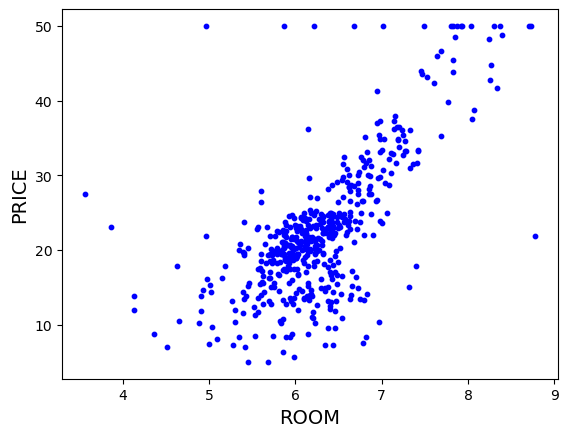

In [10]:
# 산점도를 표시
plt.scatter(x[:,1], yt, s=10, c='b')  # x[:,1]은 주어진 RM 데이터, x[:,0]은 값이 모두 1일 열
plt.xlabel('ROOM', fontsize=14)
plt.ylabel('PRICE', fontsize=14)
plt.show()

In [11]:
# 예측함수 (1, x)의 값에서 예측값 yp를 계산
def pred(x, w):
    return x @ w  # x.shape은 (506,2), w.shape은 (2,), @는 행렬 곱, (506,) 배열

In [18]:
# 초기화 처리 (교재 p.176 참고)
w = np.zeros(x.shape[1])  # x.shape[1] = 2 (bias + RM)
learning_rate = 0.01
epochs = 1000

In [27]:
# 반복 루프 (교재 p.177 참고)
def loss_func(y, yp):
    return ((y - yp) ** 2).mean()

losses = []

for _ in range(epochs):
    yp = pred(x, w)
    loss = loss_func(yt, yp)
    losses.append(loss)
    grad = -2 * x.T @ (yt - yp) / len(yt)  # 기울기 
    w -= learning_rate * grad

In [28]:
# 최종 손실함수 초깃값과 최종값 출력 (교재 p.178 참고)
print(f"초기 손실값: {losses[0]}")
print(f"최종 손실값: {losses[-1]}")
print(f"학습된 가중치: {w}")

초기 손실값: 53.05392559048179
최종 손실값: 49.447093533861555
학습된 가중치: [-12.89220088   5.67843096]


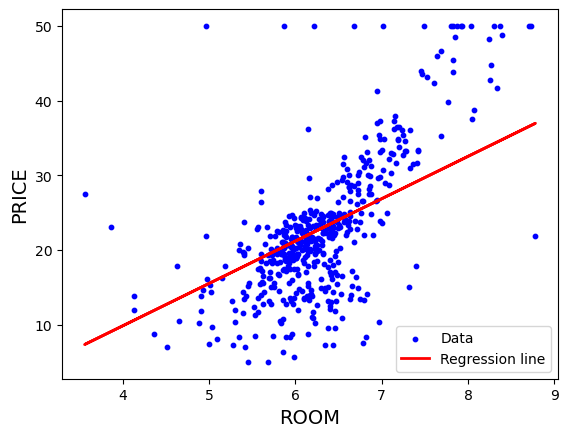

In [29]:
# 산점도와 회귀 모델 직선 그리기 (교재 p.179)
plt.scatter(x[:,1], yt, s=10, c='b', label='Data')
plt.plot(x[:,1], pred(x, w), color='r', linewidth=2, label='Regression line')
plt.xlabel('ROOM', fontsize=14)
plt.ylabel('PRICE', fontsize=14)
plt.legend()
plt.show()

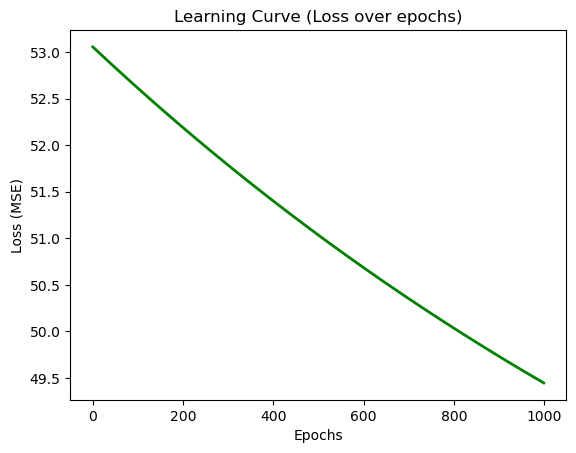

In [30]:
# 학습 곡선(손실함수 값 그래프) 표시 (교재 p.180)
plt.plot(range(epochs), losses, color='green', linewidth=2)
plt.title('Learning Curve (Loss over epochs)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.show()


질문: 이 데이터를 학습해 얻은 모델 식을 적으시오. (HINT: w값 출력)

